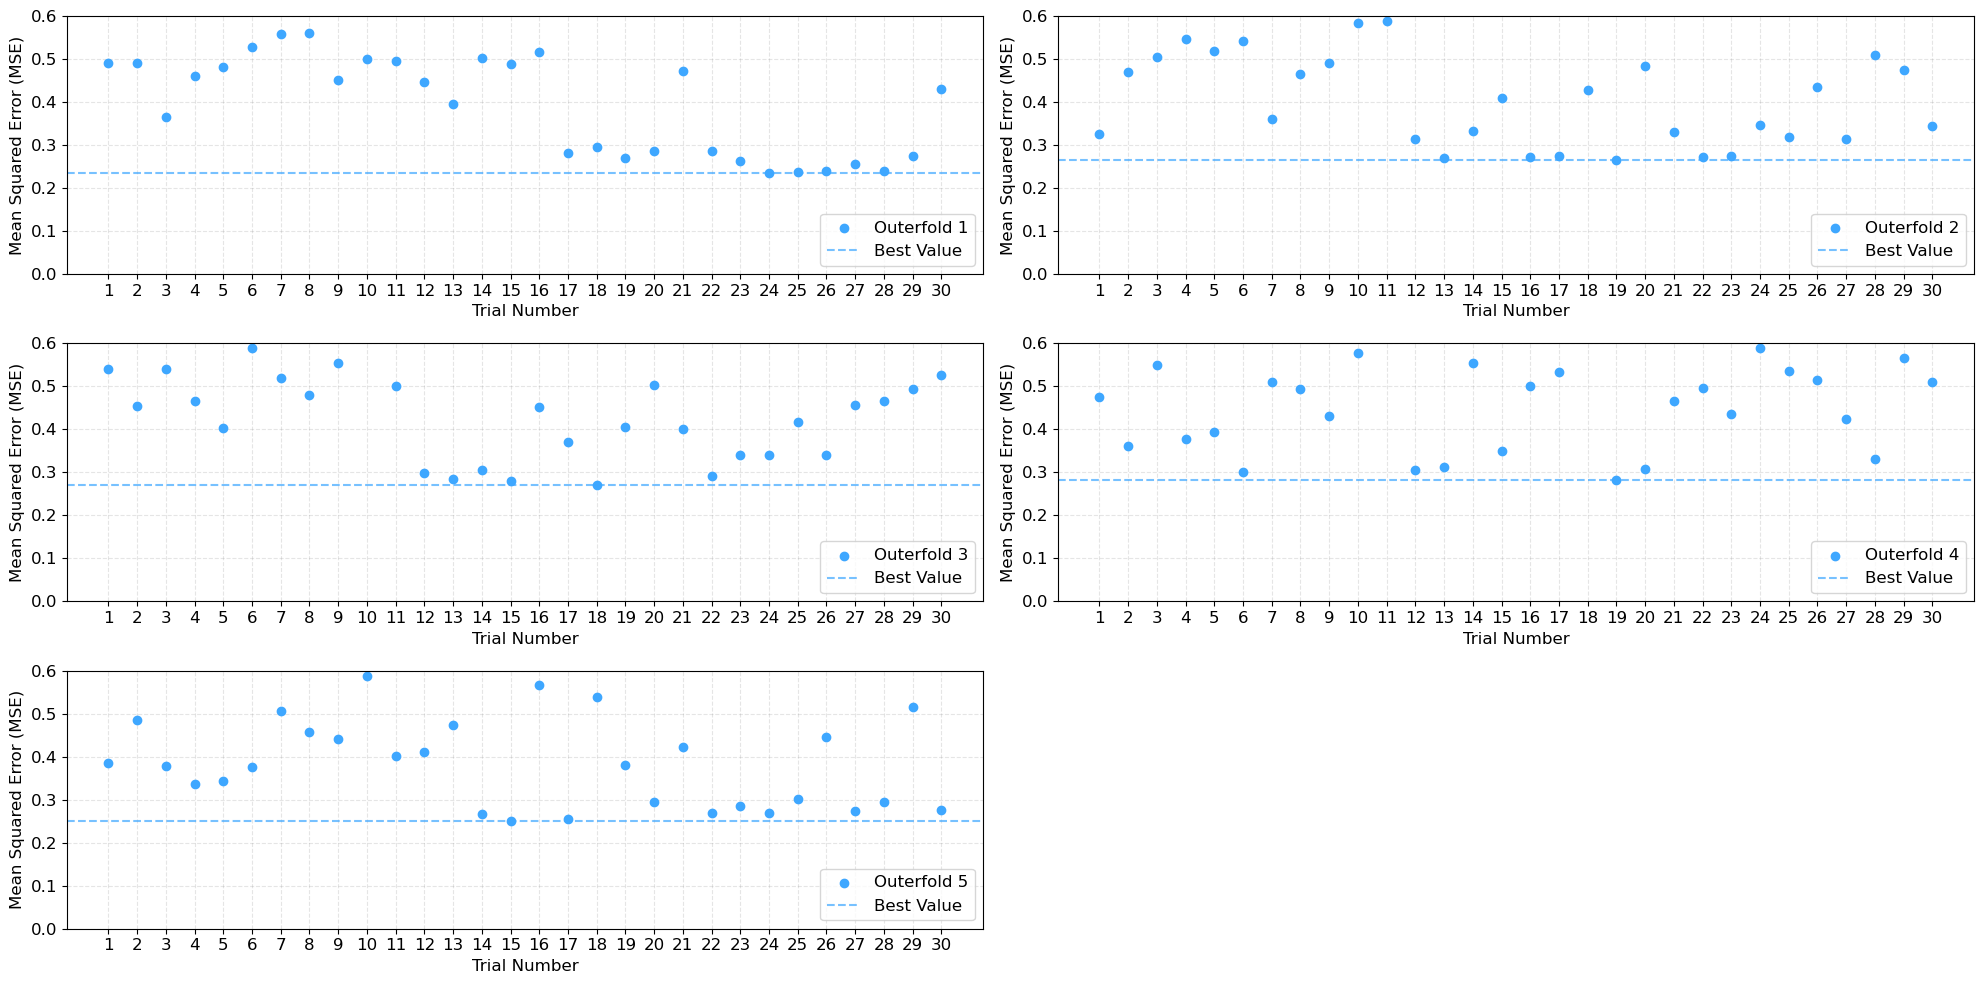

In [ ]:

import optuna
import plotly.io as pio
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams.update({'font.size': 12,'grid.color': 'gray', 'grid.linestyle': '--'  })
colors = ["#F35965", "#6BF178", "#3EA7FF", "#8633A8", "#30D5C8", "#DC8DC4"]

# pio.renderers.default = "vscode"

SEED = 15
ds = 'full_dataset'
timestamp = "20251114_074600"

optuna_db = f'../model_results/{ds}/lgb_b3db_drug_like_labelled_{SEED}_{ds}_final_{timestamp}.db'
optuna_study_name_root = f'lgb_b3db_drug_like_labelled_{SEED}_{ds}_final' 


nrows, ncols = 3, 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 10))
axes = axes.flatten()  

all_hyperparameters = []
for outerfold in range(1,6): 

    ax = axes[outerfold-1]

    outerfold_study = optuna.load_study(study_name=f"{optuna_study_name_root}_outerfold_{outerfold}", storage=f"sqlite:///{optuna_db}")
    trial_numbers, objective_values = [], []

    for t in outerfold_study.trials:
        if t.value is not None:
            trial_numbers.append(t.number)
            objective_values.append(t.value)

    trial = outerfold_study.best_trial
    
    all_hyperparameters.append(trial.params) #.items()

    ax.grid(True, zorder=0, alpha=0.2, linestyle='--')
    ax.scatter(range(1,31), objective_values, color=colors[2], marker='o', linestyle='-', zorder=2, label=f'Outerfold {outerfold}')
    ax.set_xticks(range(1,31))
    ax.set_xticklabels(range(1, 31), fontsize=12)
    ax.set_xlabel("Trial Number")
    ax.set_ylabel("Mean Squared Error (MSE)")
    ax.set_ylim((0,0.6))

    best_value = outerfold_study.best_value
    ax.axhline(best_value, color=colors[2], linestyle='--',alpha=0.7, label=f'Best Value')
    ax.legend(loc="lower right")
    # ax.savefig()
    # ax.show()

ax = axes[5]
ax.set_axis_off()

fig.tight_layout()
fig.savefig(f'../model_results/{ds}/training_hpt_plots_{SEED}_{ds}.png', dpi=300)
plt.show()


outerfold_hp_df = pd.DataFrame(all_hyperparameters, index=range(1,6))
outerfold_hp_df.to_csv(f'../model_results/{ds}/training_hyperparameter_values_{SEED}_{ds}.csv')


